<a href="https://colab.research.google.com/github/devdatta1429/BDA_Assignments/blob/main/PML/Day_22_10_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔰Decison Tree🔰

In [7]:
from google.colab import drive
drive.mount('/content/drive')


import numpy as np
import pandas as pd

import os
os.chdir('/content/drive/MyDrive/CDAC/')

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

from numpy import random
from collections import Counter

from numpy.linalg import inv
from numpy.linalg import eig

import matplotlib
from matplotlib import pyplot as plt

import seaborn as sns

import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy.stats import chisquare
from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

from scipy.stats import f
from sklearn.metrics import mean_squared_error

from sklearn.metrics import roc_auc_score

#========================================================================

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.discrete.discrete_model import MNLogit

import sklearn
from sklearn.model_selection import train_test_split



import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# from category_encoders import BinaryEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


Mounted at /content/drive


In [8]:
df = pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis =1)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [11]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [12]:
df.Age = df.Age.fillna(df.Age.median())

In [13]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [14]:
df.Embarked = df.Embarked.fillna('S')

In [15]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [16]:
df['Numpass'] = df.SibSp + df.Parch

In [17]:
df.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Numpass
0,0,3,male,22.0,1,0,7.2500,S,1
1,1,1,female,38.0,1,0,71.2833,C,1


In [18]:
df = df.drop(['SibSp' , 'Parch'] , axis =1)
df.head(2)

,Survived,Pclass,Sex,Age,Fare,Embarked,Numpass
0,0,3,male,22.0,7.2500,S,1
1,1,1,female,38.0,71.2833,C,1


In [19]:
dum_Pclass = pd.get_dummies(df.Pclass,drop_first=True,prefix='Pclass').astype(int)
dum_sex = pd.get_dummies(df.Sex,drop_first=True,prefix='Gender').astype(int)
dum_embarked = pd.get_dummies(df.Embarked,drop_first=True,prefix='Embark').astype(int)


In [20]:

df = df.drop(['Pclass','Sex','Embarked'],axis=1)
df = pd.concat([df,dum_Pclass,dum_sex,dum_embarked], axis=1)

In [21]:
df

,Survived,Age,Fare,Numpass,Pclass_2,Pclass_3,Gender_male,Embark_Q,Embark_S
0,0,22.0,7.2500,1,0,1,1,0,1
1,1,38.0,71.2833,1,0,0,0,0,0
2,1,26.0,7.9250,0,0,1,0,0,1
3,1,35.0,53.1000,1,0,0,0,0,1
4,0,35.0,8.0500,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...
886,0,27.0,13.0000,0,1,0,1,0,1
887,1,19.0,30.0000,0,0,0,0,0,1
888,0,28.0,23.4500,3,0,1,0,0,1
889,1,26.0,30.0000,0,0,0,1,0,0


In [22]:
x=df.drop('Survived',axis=1)
y=df.Survived

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

dtc.fit(x_train,y_train)


dtc.score(x_train,  y_train) # percent age in accuracy on trainining set
dtc.score(x_test , y_test) # percent age in accuracy on testing set


print(dtc.score(x_train,  y_train))
print(dtc.score(x_test , y_test))

0.9845505617977528
0.8044692737430168


When we create a Decision Tree Classifier without specifying its hyperparameters,\
there can be a large difference between the training accuracy and the testing accuracy. This indicates that the model is **overfitted**.

from above we can see there is overfitting.\
the model has learned noise also.\
the bias has been reduced and variance is increased

In [23]:
x=df.drop('Survived',axis=1)
y=df.Survived

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(max_depth = 3)

dtc.fit(x_train,y_train)

dtc.score(x_train,  y_train)
dtc.score(x_test , y_test)


print(dtc.score(x_train,  y_train))
print(dtc.score(x_test , y_test))

0.8258426966292135
0.8156424581005587


In [24]:
y_pred = dtc.predict(x_test)

In [25]:
print(confusion_matrix(y_test , y_pred))

[[107   5]
 [ 28  39]]


In [26]:
(107+39)/(107+39+28+5)

0.8156424581005587

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* min_impurity_decrease


HyperParameter :

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [27]:
param = {'max_depth':[2,3,4,5,6,7],
         'splitter':['best','random'],
         'criterion':['gini','entropy'],
         'min_samples_leaf':[2,3,4,5,6]}

from sklearn.model_selection import GridSearchCV

mod1 = GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
mod1.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=3),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, 7],
                         'min_samples_leaf': [2, 3, 4, 5, 6],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [28]:
mod1.best_params_

{'criterion': 'gini',
 'max_depth': 7,
 'min_samples_leaf': 6,
 'splitter': 'best'}

In [29]:
x=df.drop('Survived',axis=1)
y=df.Survived

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(criterion = 'gini',
                            max_depth = 5,
                            min_samples_leaf= 2,
                            splitter= 'best')

dtc.fit(x_train,y_train)

dtc.score(x_train,  y_train)
dtc.score(x_test , y_test)


print(dtc.score(x_train,  y_train))
print(dtc.score(x_test , y_test))

0.8469101123595506
0.8156424581005587


In [30]:
df = pd.read_csv('Titanic.csv')

df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)
df.info()
df.Age = df.Age.fillna(df.Age.median())
df.Embarked.mode()
df.Embarked = df.Embarked.fillna('S')

df['NumPass'] = df.SibSp + df.Parch
df = df.drop(['SibSp','Parch'], axis=1)

dum_Pclass = pd.get_dummies(df.Pclass,drop_first=True,prefix='Pclass').astype(int)
dum_sex = pd.get_dummies(df.Sex,drop_first=True,prefix='Gender').astype(int)
dum_embarked = pd.get_dummies(df.Embarked,drop_first=True,prefix='Embark').astype(int)

df = df.drop(['Pclass','Sex','Embarked'],axis=1)
df = pd.concat([df,dum_Pclass,dum_sex,dum_embarked], axis=1)

x=df.drop('Survived',axis=1)
y=df.Survived

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

from sklearn.tree import DecisionTreeClassifier

# define instance for DecisionTreeClassifier WITHOUT hyperparameters
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)
dtc.score(x_train,y_train)   # %age accuracy on training set
dtc.score(x_test,y_test)
# the big gap between training and test accuracy suggests overfitting

# to remove overfitting, hyper parameter values need to be set
# to get the best values for the the hyperparameters we do the Grid Search CV

param = {'max_depth':[2,3,4,5,6,7,8],
         'splitter':['best','random'],
         'criterion':['gini','entropy'],
         'min_samples_leaf':[2,3,4,5,6]}

from sklearn.model_selection import GridSearchCV

mod1 = GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
mod1.fit(x_train,y_train)

mod1.best_params_

# the above command gives the most appropriate values for the different hyperparameters

# define the instance dtc WITH hyperparameters
dtc = DecisionTreeClassifier(criterion='gini',
 max_depth=5,
 min_samples_leaf=2,
 splitter='best')

dtc.fit(x_train,y_train)
dtc.score(x_train,y_train)   # %age accuracy on training set
dtc.score(x_test,y_test)

y_pred = dtc.predict(x_test)

print(confusion_matrix(y_test,y_pred))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
[[106   6]
 [ 27  40]]


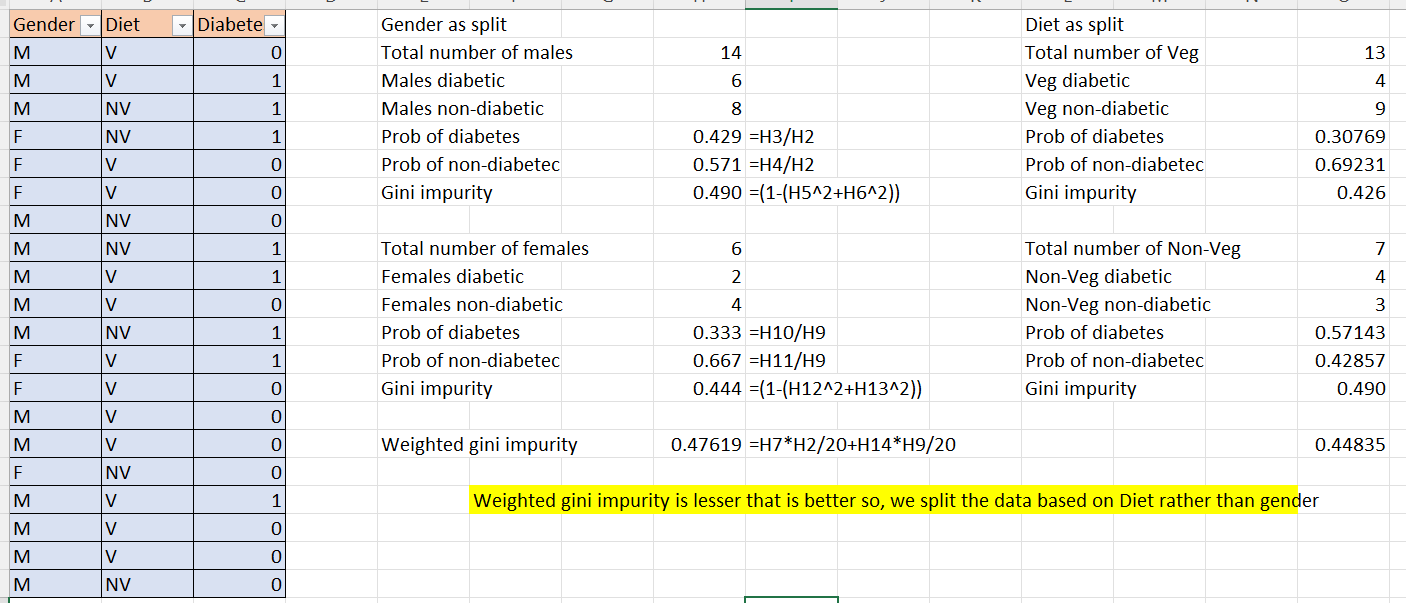

In [32]:
np.log(1 )

np.float64(0.0)

In [34]:
df = pd.read_excel('SalesData.xlsx')

In [35]:
df.head(2)

,Sales,Ad_Budget,Store_Size,Region
0,268.093732,44,2836,East
1,441.660841,96,2656,North


In [36]:
df = pd.read_excel('SalesData.xlsx')
dum_Region = pd.get_dummies(df.Region,drop_first=True,prefix='Reg').astype(int)
df = df.drop('Region', axis=1)
df = pd.concat([df,dum_Region], axis=1)

x = df.drop('Sales', axis=1)
y = df.Sales

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

from sklearn.tree import DecisionTreeRegressor


0.8540132504557271

In [45]:
# define instance for DecisionTreeClassifier WITHOUT hyperparameters
dtr = DecisionTreeRegressor()
print(dtr)
dtr.fit(x_train,y_train)

DecisionTreeRegressor()


DecisionTreeRegressor()

In [46]:
dtr.score(x_train,y_train)
dtr.score(x_test,y_test)

print(dtr.score(x_train,y_train))
print(dtr.score(x_test,y_test))

1.0
0.8572483806336965


In [52]:
from sklearn.metrics import r2_score
y_pred = dtr.predict(x_test)

r2_score(y_test, y_pred)

0.8572483806336965

In [53]:
params = {'max_depth' : [3,4,5,6,7],
          'min_samples_split' :[2,3,4,5],
          'min_samples_leaf' :[2,3,4,5]}

In [66]:
mod1 = GridSearchCV(dtr , param_grid = params, cv=5 , scoring='accuracy')
mod1

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [3, 4, 5, 6, 7],
                         'min_samples_leaf': [2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4, 5]},
             scoring='accuracy')

In [67]:
mod1.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [3, 4, 5, 6, 7],
                         'min_samples_leaf': [2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4, 5]},
             scoring='accuracy')

In [68]:
mod1.best_params_

{'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

In [69]:
dtr = DecisionTreeRegressor(max_depth=3,min_samples_leaf=2, min_samples_split=2)
dtr.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=2)

In [70]:
dtr.score(x_train,y_train)
dtr.score(x_test,y_test)

print(dtr.score(x_train,y_train))
print(dtr.score(x_test,y_test))

0.8368972794176226
0.8058459798835955
